# Monitoreo de Especies Invasoras en Galápagos con Google Earth Engine

## 1. Adquisición - Conexión a GEE y descarga de ImageCollection

In [ ]:
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests
from PIL import Image
from io import BytesIO


In [4]:
# Autenticación, solo lo ejecutamos una vez
#ee.Initialize(project='galapagossafe')

#### Área de Estudio: Tierras altas de Santa Cruz
Las tierras altas húmedas (> 200m) son el principal frente de invasión de mora y guayaba sobre el bosque de Sacalesia.

In [13]:
santa_cruz = ee.Geometry.Rectangle([-90.45, -0.75, -90.20, -0.55])

# ImageCollection Sentinel-2 SR — Usaremos dos períodos para comparar el cambio
def get_collection(start, end):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(santa_cruz)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) # 20% menos de nubes
        .sort('system:time_start')
    )

col_2020 = get_collection('2020-06-01', '2020-12-31')  # Período base
col_2023 = get_collection('2023-06-01', '2023-12-31')  # Período reciente

print(f'Imágenes 2020 (base)   : {col_2020.size().getInfo()}')
print(f'Imágenes 2023 (reciente): {col_2023.size().getInfo()}')

Imágenes 2020 (base)   : 12
Imágenes 2023 (reciente): 7


## 2. Pre-procesamiento - Clipping y Remoción de Nubes

In [14]:
# ── Máscara de nubes con SCL (Scene Classification Layer) ────────────────────
def mask_clouds(image):
    """Elimina nubes, sombras y cirrus usando la banda SCL de Sentinel-2."""
    scl = image.select('SCL')
    # 3=sombra, 8=nube media, 9=nube alta, 10=cirrus, 11=nieve
    mask = (scl.neq(3).And(scl.neq(8))
               .And(scl.neq(9)).And(scl.neq(10)))
    return image.updateMask(mask)

# ── Escalar reflectancias Sentinel-2 (dividir por 10000) ─────────────────────
def scale_bands(image):
    """Convierte DN a reflectancia de superficie [0-1]."""
    optical = image.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
    return (image
            .addBands(optical.divide(10000), overwrite=True)
            .copyProperties(image, ['system:time_start']))

# ── Pipeline completo ─────────────────────────────────────────────────────────
def preprocess(collection):
    return (collection
            .map(mask_clouds)
            .map(scale_bands)
            .map(lambda img: img.clip(santa_cruz)))

proc_2020 = preprocess(col_2020)
proc_2023 = preprocess(col_2023)

# Composites medianos (reducen ruido residual de nubes)
comp_2020 = proc_2020.median()
comp_2023 = proc_2023.median()

print('✅ Pre-procesamiento completo: clipping + nubes + escala de reflectancias')

print(f'Imágenes 2020 procesadas: {proc_2020.size().getInfo()}')
print(f'Imágenes 2023 procesadas: {proc_2023.size().getInfo()}')

✅ Pre-procesamiento completo: clipping + nubes + escala de reflectancias
Imágenes 2020 procesadas: 12
Imágenes 2023 procesadas: 7


## 3. Visualización de las Imágenes

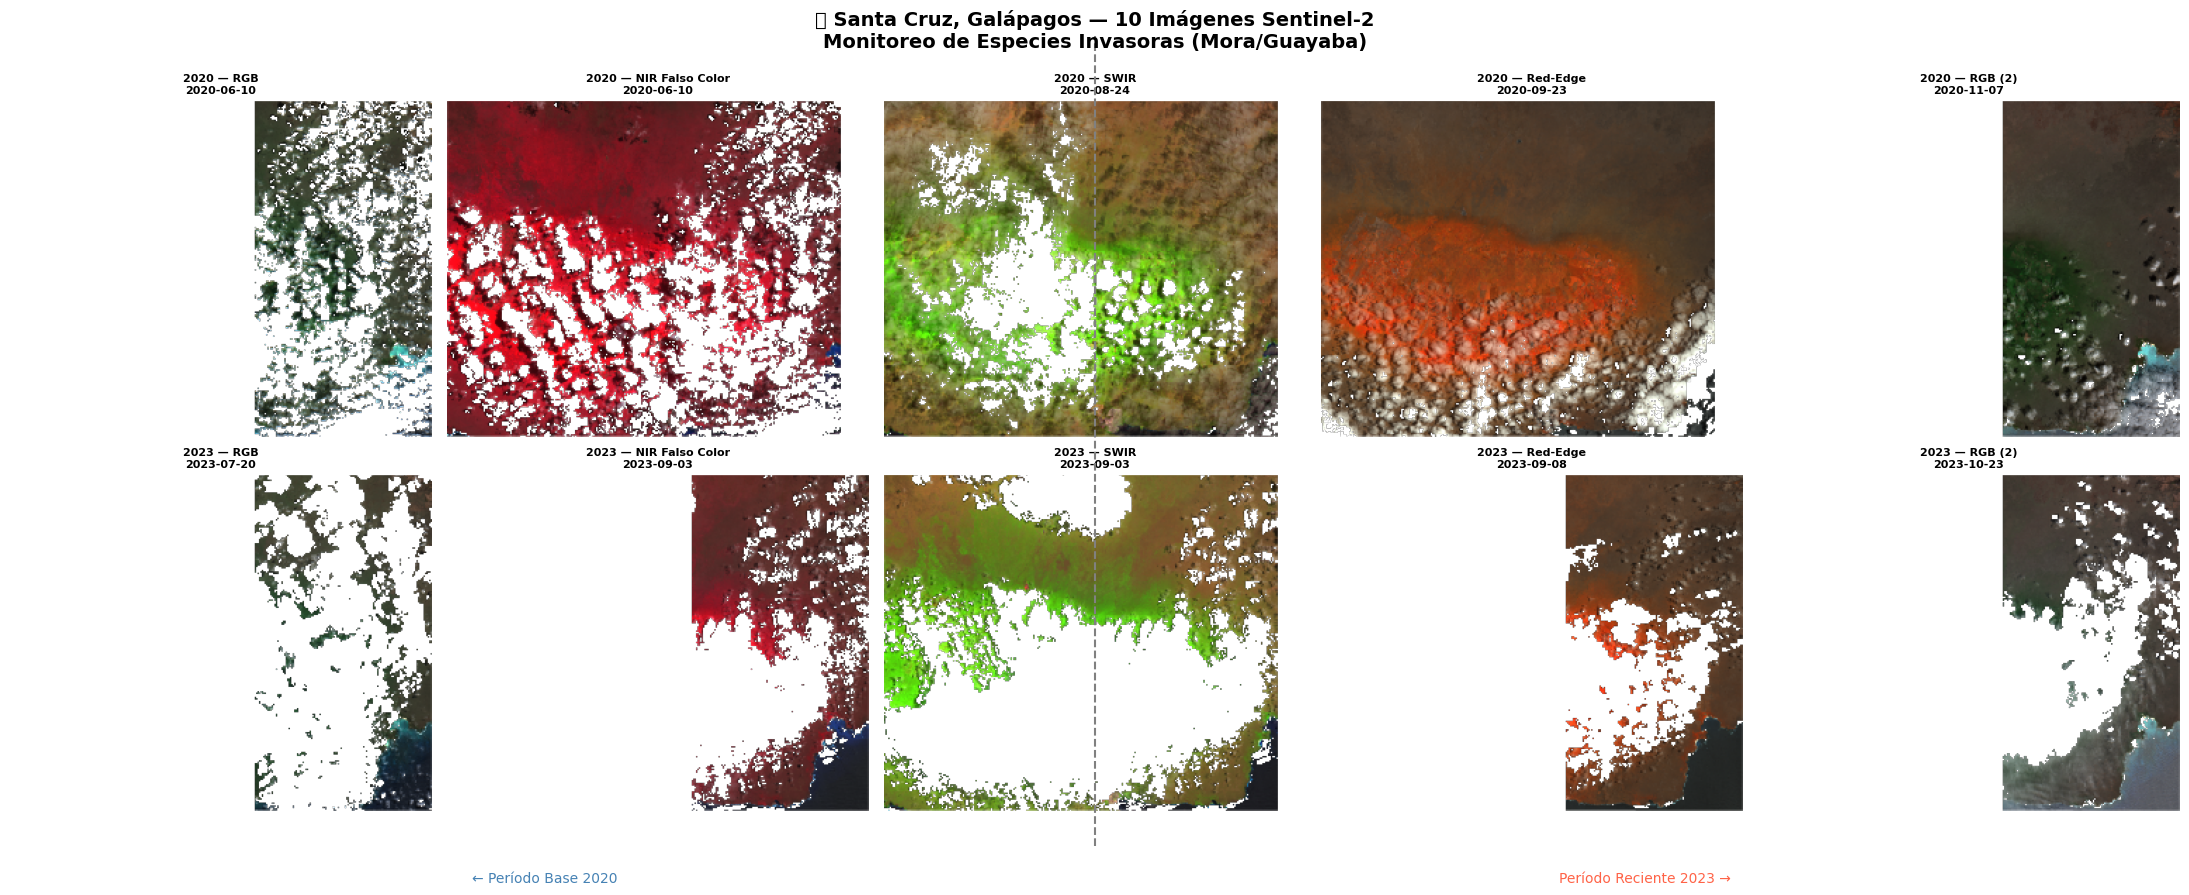

10 imágenes visualizadas (5×2020, 5×2023 — RGB, NIR, SWIR, Red-Edge)


In [16]:
# ── Función auxiliar para descargar thumbnails de GEE ────────────────────────
def get_thumb(image, vis_params, region=santa_cruz, dim=300):
    url = image.getThumbURL({**vis_params, 'region': region,
                             'dimensions': dim, 'format': 'png'})
    resp = requests.get(url)
    return Image.open(BytesIO(resp.content))

# Parámetros de visualización
vis_rgb  = {'min': 0.0, 'max': 0.3,  'bands': ['B4','B3','B2']}
vis_nir  = {'min': 0.0, 'max': 0.5,  'bands': ['B8','B4','B3']}   # Falso color
vis_swir = {'min': 0.0, 'max': 0.5,  'bands': ['B11','B8','B4']}  # SWIR — útil para vegetación densa
vis_rededge = {'min': 0.0, 'max': 0.5, 'bands': ['B7','B5','B4']} # Red-Edge — sensible a dosel

# Seleccionar 5 imágenes de 2020 y 5 de 2023
imgs_2020 = proc_2020.toList(5)
imgs_2023 = proc_2023.toList(5)

configs = [
    (imgs_2020, 0, vis_rgb,     '2020 — RGB'),
    (imgs_2020, 1, vis_nir,     '2020 — NIR Falso Color'),
    (imgs_2020, 2, vis_swir,    '2020 — SWIR'),
    (imgs_2020, 3, vis_rededge, '2020 — Red-Edge'),
    (imgs_2020, 4, vis_rgb,     '2020 — RGB (2)'),
    (imgs_2023, 0, vis_rgb,     '2023 — RGB'),
    (imgs_2023, 1, vis_nir,     '2023 — NIR Falso Color'),
    (imgs_2023, 2, vis_swir,    '2023 — SWIR'),
    (imgs_2023, 3, vis_rededge, '2023 — Red-Edge'),
    (imgs_2023, 4, vis_rgb,     '2023 — RGB (2)'),
]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('🌿 Santa Cruz, Galápagos — 10 Imágenes Sentinel-2\n'
             'Monitoreo de Especies Invasoras (Mora/Guayaba)',
             fontsize=14, fontweight='bold')

for idx, (col_list, img_idx, vis, titulo) in enumerate(configs):
    ax = axes[idx // 5][idx % 5]
    img = ee.Image(col_list.get(img_idx))
    date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    thumb = get_thumb(img, vis)
    ax.imshow(thumb)
    ax.set_title(f'{titulo}\n{date}', fontsize=8, fontweight='bold')
    ax.axis('off')

# Separador visual entre años
fig.add_artist(plt.Line2D([0.5, 0.5], [0.05, 0.95],
               transform=fig.transFigure, color='gray', lw=1.5, linestyle='--'))
fig.text(0.25, 0.01, '← Período Base 2020', ha='center', fontsize=10, color='steelblue')
fig.text(0.75, 0.01, 'Período Reciente 2023 →', ha='center', fontsize=10, color='tomato')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('galapagos_10_imagenes.png', dpi=150, bbox_inches='tight')
plt.show()
print('10 imágenes visualizadas (5×2020, 5×2023 — RGB, NIR, SWIR, Red-Edge)')

## Lógica Inicial - Índices Espectrales y Clasificación de Cobertura

Las especies invasoras (mora, guayaba) y el bosque de Scalesia tienen firmas espectrales distintas:

| Cobertura | NDVI | EVI | Descripción |
|-----------|------|-----|-------------|
| **Scalesia** (nativa) | 0.5–0.8 | Alto | Dosel denso, copas redondeadas |
| **Guayaba / Mora** (invasoras) | 0.6–0.9 | Muy alto | Vegetación muy densa, continua |
| **Pastizal / zona degradada** | 0.1–0.4 | Bajo | Cobertura dispersa |
| **Agua / suelo** | < 0.1 | — | Sin vegetación |

In [17]:
# ── Calcular índices en ambos composites ──────────────────────────────────────

def calcular_indices(img):
    """Calcula NDVI, EVI y NDWI sobre un composite Sentinel-2 escalado."""

    # NDVI — Normalized Difference Vegetation Index
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # EVI — Enhanced Vegetation Index (menos saturación en dosel denso)
    # EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = img.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {'NIR': img.select('B8'), 'RED': img.select('B4'), 'BLUE': img.select('B2')}
    ).rename('EVI')

    # NDWI — índice de agua (detecta ríos, zonas húmedas)
    ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')

    return ndvi, evi, ndwi

ndvi_2020, evi_2020, ndwi_2020 = calcular_indices(comp_2020)
ndvi_2023, evi_2023, ndwi_2023 = calcular_indices(comp_2023)

print('Índices calculados: NDVI, EVI, NDWI — para 2020 y 2023')

Índices calculados: NDVI, EVI, NDWI — para 2020 y 2023


In [18]:
# ── Clasificación de cobertura por umbrales ───────────────────────────────────
# Clases:
#   0 — Agua / suelo desnudo  (NDVI < 0.1)
#   1 — Pastizal / degradado  (NDVI 0.1–0.4)
#   2 — Bosque Scalesia        (NDVI 0.4–0.65, EVI moderado)
#   3 — Invasoras densas       (NDVI > 0.65, EVI alto — mora/guayaba)

def clasificar(ndvi, evi):
    agua_suelo  = ndvi.lt(0.1)                                   # clase 0
    pastizal    = ndvi.gte(0.1).And(ndvi.lt(0.4))               # clase 1
    scalesia    = ndvi.gte(0.4).And(ndvi.lt(0.65))              # clase 2
    invasoras   = ndvi.gte(0.65)                                 # clase 3

    clasificacion = (
        agua_suelo.multiply(0)
        .add(pastizal.multiply(1))
        .add(scalesia.multiply(2))
        .add(invasoras.multiply(3))
    ).rename('cobertura')
    return clasificacion

clases_2020 = clasificar(ndvi_2020, evi_2020)
clases_2023 = clasificar(ndvi_2023, evi_2023)

# Mapa de cambio: zonas que pasaron de Scalesia (2) a Invasoras (3)
avance_invasoras = clases_2023.eq(3).And(clases_2020.eq(2)).rename('avance')

print('✅ Clasificación de cobertura aplicada (4 clases) para 2020 y 2023')
print('✅ Mapa de avance de invasoras calculado (Scalesia→Invasoras)')

✅ Clasificación de cobertura aplicada (4 clases) para 2020 y 2023
✅ Mapa de avance de invasoras calculado (Scalesia→Invasoras)


NameError: name 'mpatches' is not defined

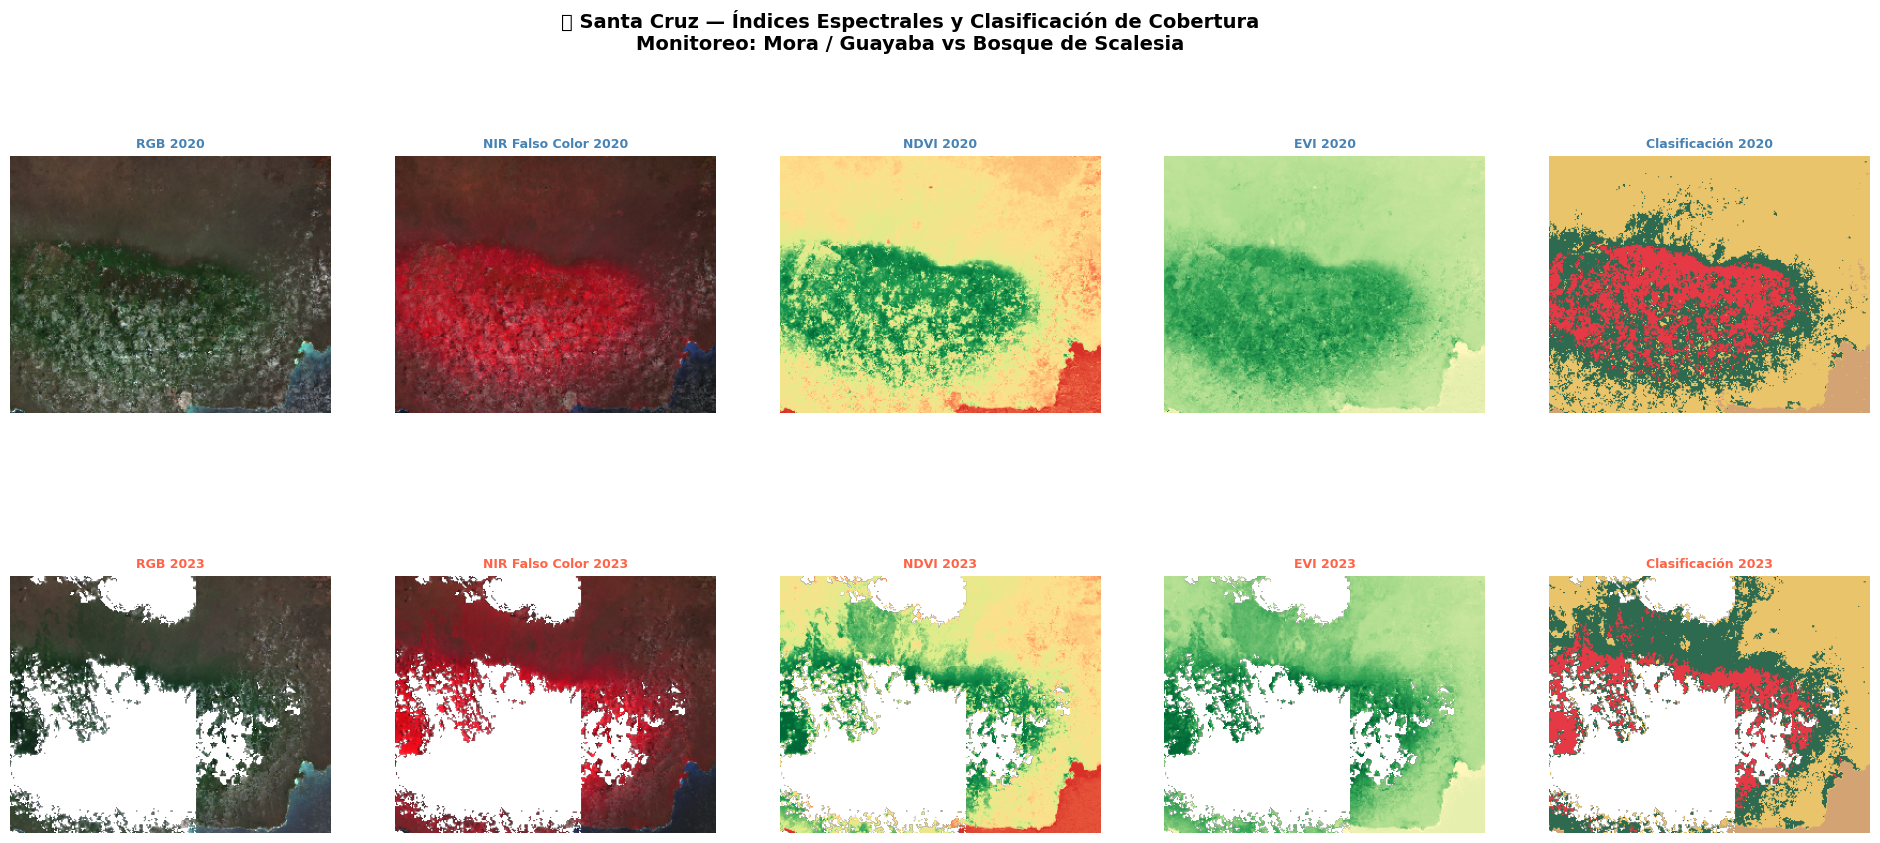

In [19]:
# ── Visualizar índices y clasificación ───────────────────────────────────────
vis_ndvi  = {'min': -0.1, 'max': 0.9,
             'palette': ['#d73027','#fc8d59','#fee08b','#d9ef8b','#1a9850','#006837']}
vis_evi   = {'min': -0.1, 'max': 0.8,
             'palette': ['#fff7bc','#addd8e','#31a354','#006837']}
vis_clas  = {'min': 0, 'max': 3,
             'palette': ['#d4a373','#e9c46a','#2d6a4f','#e63946']}  # suelo/pastizal/scalesia/invasoras
vis_avance = {'min': 0, 'max': 1, 'palette': ['#f0f0f0','#e63946']}

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('🌿 Santa Cruz — Índices Espectrales y Clasificación de Cobertura\n'
             'Monitoreo: Mora / Guayaba vs Bosque de Scalesia',
             fontsize=14, fontweight='bold')

celdas = [
    # Fila 1: período 2020
    (comp_2020,    vis_rgb,   'RGB 2020'),
    (comp_2020,    vis_nir,   'NIR Falso Color 2020'),
    (ndvi_2020,    vis_ndvi,  'NDVI 2020'),
    (evi_2020,     vis_evi,   'EVI 2020'),
    (clases_2020,  vis_clas,  'Clasificación 2020'),
    # Fila 2: período 2023
    (comp_2023,    vis_rgb,   'RGB 2023'),
    (comp_2023,    vis_nir,   'NIR Falso Color 2023'),
    (ndvi_2023,    vis_ndvi,  'NDVI 2023'),
    (evi_2023,     vis_evi,   'EVI 2023'),
    (clases_2023,  vis_clas,  'Clasificación 2023'),
]

for idx, (img_ee, vis, titulo) in enumerate(celdas):
    ax = axes[idx // 5][idx % 5]
    thumb = get_thumb(img_ee, vis)
    ax.imshow(thumb)
    color = 'steelblue' if idx < 5 else 'tomato'
    ax.set_title(titulo, fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

# Leyenda clasificación
leyenda = [
    mpatches.Patch(color='#d4a373', label='Suelo / Agua'),
    mpatches.Patch(color='#e9c46a', label='Pastizal / Degradado'),
    mpatches.Patch(color='#2d6a4f', label='Bosque Scalesia (nativo)'),
    mpatches.Patch(color='#e63946', label='Invasoras densas (Mora/Guayaba)'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('galapagos_clasificacion_cobertura.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización completa: índices + clasificación 2020 vs 2023')

In [11]:
# ── Estadísticas de cobertura ─────────────────────────────────────────────────
stats_ndvi = ndvi.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.minMax(), sharedInputs=True),
    geometry=galapagos,
    scale=1000,
    maxPixels=1e9
).getInfo()

print('📊 Estadísticas NDVI en Galápagos (2023):')
print(f"   Media : {stats_ndvi.get('NDVI_mean',  'N/A'):.4f}")
print(f"   Mínimo: {stats_ndvi.get('NDVI_min',   'N/A'):.4f}")
print(f"   Máximo: {stats_ndvi.get('NDVI_max',   'N/A'):.4f}")
print()
print('🌿 NDVI > 0.3  → Vegetación densa')
print('🏜️  NDVI < 0.1  → Suelo desnudo / lava volcánica')
print('💧 NDWI > 0.1  → Presencia de agua')

📊 Estadísticas NDVI en Galápagos (2023):
   Media : -0.0513
   Mínimo: -0.2721
   Máximo: 0.8828

🌿 NDVI > 0.3  → Vegetación densa
🏜️  NDVI < 0.1  → Suelo desnudo / lava volcánica
💧 NDWI > 0.1  → Presencia de agua


In [12]:
# ── Mapa interactivo con geemap ───────────────────────────────────────────────
Map = geemap.Map(center=[-0.5, -90.5], zoom=8)

Map.addLayer(composite,     {'min': 0, 'max': 3000, 'bands': ['B4','B3','B2']}, 'RGB Compuesto')
Map.addLayer(composite,     {'min': 0, 'max': 4000, 'bands': ['B8','B4','B3']}, 'NIR Falso Color')
Map.addLayer(ndvi,          {'min': -0.2, 'max': 0.8, 'palette': ['#d73027','#fee08b','#1a9850']}, 'NDVI')
Map.addLayer(clasificacion, {'min': 0, 'max': 2,   'palette': ['#b5651d','#228B22','#1E90FF']}, 'Segmentación')

Map.addLayerControl()
Map

Map(center=[-0.5, -90.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…